In [ ]:
df_daily.replace([np.inf, -np.inf], np.nan, inplace=True)
df_daily.dropna(inplace=True)

In [ ]:
X_train, y_train = (
    train.drop(["electricity_demand_values"], axis=1),
    train["electricity_demand_values"],
)


X_test, y_test = (
    test.drop(["electricity_demand_values"], axis=1),
    test["electricity_demand_values"],
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

In [ ]:
gd_reg = GradientBoostingRegressor(learning_rate=0.1, max_depth=3, n_estimators=500)
df_results = train_model(X_train, y_train, X_test, y_test, gd_reg)

In [ ]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    df_daily[features],
    df_daily["electricity_demand_values"],
    test_size=0.2,
    random_state=42,
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)


r2_ls = []
rmse_ls = []

for train_index, val_index in kf.split(X_trainval):
    X_train, X_val = (
        X_trainval.iloc[train_index],
        X_trainval.iloc[val_index],
    )
    y_train, y_val = (
        y_trainval[train_index],
        y_trainval[val_index],
    )
    gd_reg.fit(X_train, y_train)
    y_val_pred = gd_reg.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    rmse_ls.append(rmse)
    r2_ls.append(r2)
    print(f"RMSE: {rmse}")
    print(f"R^2 Score: {r2}")

In [ ]:
y_test_pred = gd_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = np.mean(np.abs(y_test_pred - y_test))
r2 = r2_score(y_test, y_test_pred)
print(f"RMSE on test: {rmse:.4f}")
print(f"MAE on test: {mae:.4f}")
print(f"R2 on test: {r2:.4f}")

In [ ]:
# train, test = split_data(
#     df_daily.query("Time >= '2017-01-01' & Time <= '2018-11-20'"), "2018-06-01"
# )

In [ ]:
# df_monthly_electricity_demand = (
#     df_daily["electricity_demand_values"].resample("M").mean()
# )

# monthly_avg_over_years = df_daily['electricity_demand_values'].resample('M').mean().groupby([lambda x: x.month]).mean()
# monthly_avg_over_years

# monthly_avg_dict = monthly_avg_over_years.to_dict()
# df_daily["monthly_avg"] = df_daily.index.month.map(monthly_avg_dict)

In [ ]:
_, ax = plt.subplots(figsize=(12, 3))

ax.plot(
    df_daily["electricity_demand_values"].resample("M").mean(),
    marker="o",
    ms=3,
    linestyle="-",
    label="mean",
)
ax.plot(
    df_daily["electricity_demand_values"].resample("M").max(),
    ms=3,
    linestyle="-",
    label="max",
)
ax.plot(
    df_daily["electricity_demand_values"].resample("M").min(),
    ms=3,
    linestyle="-",
    label="min",
)
ax.set_title("Daily Electricity Demand 2010 - 2018 (Monthly)")

plt.legend()
plt.tight_layout()

In [ ]:
df.describe().T

## Create daily dataframe and feature creation
# Collect allavailable solar irradiation data in a day
df["solar_irridiation_positive"] = df["solar_irridiation"][df["solar_irridiation"] > 0]
df["solar_irridiation_positive"].resample(
    "D"
).count().value_counts()  # 13 hours solar irradiation per day
df["solar_irridiation"][df["solar_irridiation"] == 0].resample(
    "D"
).count().value_counts()  # 11 hours no solar irradiation per day
df_daily = pd.DataFrame()

mean_cols = [
    "air_pressure",
    "air_temperature",
    "relative_humidity",
    "wind_speed",
    "solar_irridiation_positive",
    "total_cloud_cover_percent",
]

for _ in mean_cols:
    df_daily[_] = df[_].resample("D").mean()
df_daily["electricity_demand_values"] = (
    df["electricity_demand_values"].resample("D").sum()
)

daily_resampled_temp = df["air_temperature"].resample(
    "D"
)  # resample daily data with range from hourly data
df_daily["air_temperature_range"] = (
    daily_resampled_temp.max() - daily_resampled_temp.min()
)  # calculate range of air temperature
df_daily["air_temperature_high"] = daily_resampled_temp.max()
df_daily["air_temperature_low"] = daily_resampled_temp.min()

daily_resampled_wind = df["wind_speed"].resample("D")
df_daily["wind_speed_range"] = (
    daily_resampled_wind.max() - daily_resampled_wind.min()
)  # calculate range of wind speed
df_daily.describe().T


def label_wind(wind):
    if wind < 5:
        return "Wind scale 2"
    else:
        return "Wind scale 3"


df_daily["wind_label"] = df_daily["wind_speed"].apply(label_wind)
df_wind = pd.get_dummies(df_daily["wind_label"])
for _ in df_wind.columns:
    df_daily[_] = df_wind[_].astype(int)
df_daily.drop("wind_label", axis=1, inplace=True)

df_daily.describe().T

df_daily["Day_of_Week"] = df_daily.index.day_of_week
df_daily["quarter"] = df_daily.index.quarter
df_daily["month"] = df_daily.index.month
df_daily = pd.get_dummies(
    df_daily,
    columns=["Day_of_Week", "quarter", "month"],
    prefix=["Is_Weekday", "Quarter", "month"],
)


df_daily.columns

for _ in [
    "Is_Weekday_0",
    "Is_Weekday_1",
    "Is_Weekday_2",
    "Is_Weekday_3",
    "Is_Weekday_4",
    "Is_Weekday_5",
    "Is_Weekday_6",
    "Quarter_1",
    "Quarter_2",
    "Quarter_3",
    "Quarter_4",
    "month_1",
    "month_2",
    "month_3",
    "month_4",
    "month_5",
    "month_6",
    "month_7",
    "month_8",
    "month_9",
    "month_10",
    "month_11",
    "month_12",
]:
    df_daily[_] = df_daily[_].astype(int)


def label_humidity(humidity):
    if humidity < 30:
        return "Uncomfortable Dry"  # 0
    elif humidity > 60:
        return "Uncomfortable Wet"  # 2
    else:
        return "Comfort"  # 1


df_daily["relative_humidity_label"] = df_daily["relative_humidity"].apply(
    label_humidity
)

df_humidity = pd.get_dummies(df_daily["relative_humidity_label"], prefix="huimidity")
for _ in df_humidity.columns:
    df_daily[_] = df_humidity[_].astype(int)

df_daily.drop("relative_humidity_label", axis=1, inplace=True)


def label_temperature(temp):
    if temp < -10:
        return "temp_less_nega_10"  # 0
    elif temp < 0:
        return "temp_nega_10_0"
    elif temp < 10:
        return "temp_0_10"
    elif temp < 20:
        return "temp_10_20"
    elif temp < 30:
        return "temp_20_30"
    elif temp < 40:
        return "temp_30_40"
    else:
        return "temp_greater_40"


df_daily["temp_range"] = df_daily["air_temperature"].apply(label_temperature)
df_temperature = pd.get_dummies(df_daily["temp_range"])

for _ in df_temperature.columns:
    df_daily[_] = df_temperature[_].astype(int)

df_daily.drop("temp_range", axis=1, inplace=True)

# df_daily["electricity_demand_3d_mean"] = (
#     df["electricity_demand_values"].rolling(window=3).mean()
# )
# df_daily["electricity_demand_3d_std"] = (
#     df["electricity_demand_values"].rolling(window=3).std()
# )


# df_daily["electricity_demand_7d_mean"] = (
#     df["electricity_demand_values"].rolling(window=7).mean()
# )
# df_daily["electricity_demand_7d_std"] = (
#     df["electricity_demand_values"].rolling(window=7).std()
# )


# df_daily["electricity_demand_14d_mean"] = (
#     df["electricity_demand_values"].rolling(window=14).mean()
# )
# df_daily["electricity_demand_14d_std"] = (
#     df["electricity_demand_values"].rolling(window=14).std()
# )

# df_daily["electricity_demand_21d_mean"] = (
#     df["electricity_demand_values"].rolling(window=21).mean()
# )
# df_daily["electricity_demand_21d_std"] = (
#     df["electricity_demand_values"].rolling(window=21).std()
# )


# df_daily["electricity_demand_30d_mean"] = (
#     df["electricity_demand_values"].rolling(window=30).mean()
# )
# df_daily["electricity_demand_30d_std"] = (
#     df["electricity_demand_values"].rolling(window=30).std()
# )

# df_daily.query("Time >= '2017-07-01' & Time <= '2017-07-20'")[
#     "electricity_demand_values"
# ].pct_change().shift(-1)

df_daily.info()

df_daily.describe().T

df_daily

df_daily.info()
df_daily.drop(
    ["air_temperature", "wind_speed", "relative_humidity"], axis=1, inplace=True
)
df_daily.columns


## Training and Testing models
def train_test_set(df, start, end, split_time):
    train = df[(df.index > start) & (df.index <= split_time)]
    test = df[(df.index > split_time) & (df.index <= end)]
    X_train, y_train = (
        train.drop(["electricity_demand_values"], axis=1),
        train["electricity_demand_values"],
    )
    X_test, y_test = (
        test.drop(["electricity_demand_values"], axis=1),
        test["electricity_demand_values"],
    )
    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = train_test_set(
    df_daily, "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

_, ax = plt.subplots(figsize=(12, 3))

ax.plot(y_train.index, y_train, label="Train")
ax.plot(y_test.index, y_test, label="Test")


plt.legend()
plt.tight_layout()

plt.show()

# train, test = split_data(
#     df_daily.query("Time >= '2017-01-01' & Time <= '2018-11-20'"), "2018-06-01"
# )

RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

RF_reg.fit(X_train, y_train)

y_pred = RF_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R^2 Score: {r2}")

df_results = pd.DataFrame({"Time": y_test.index, "y_test": y_test, "y_pred": y_pred})

df_results.plot(x="Time", figsize=(16, 6))

# _, ax = plt.subplots(figsize=(16, 16))

# sns.heatmap(df_daily.corr(), annot=True, ax=ax)

# plt.show()

df.describe().T

## Create daily dataframe and feature creation
# Collect allavailable solar irradiation data in a day
df["solar_irridiation_positive"] = df["solar_irridiation"][df["solar_irridiation"] > 0]
df["solar_irridiation_positive"].resample(
    "D"
).count().value_counts()  # 13 hours solar irradiation per day
df["solar_irridiation"][df["solar_irridiation"] == 0].resample(
    "D"
).count().value_counts()  # 11 hours no solar irradiation per day
df_daily = pd.DataFrame()

mean_cols = [
    "air_pressure",
    "air_temperature",
    "relative_humidity",
    "wind_speed",
    "solar_irridiation_positive",
    "total_cloud_cover_percent",
]

for _ in mean_cols:
    df_daily[_] = df[_].resample("D").mean()
df_daily["electricity_demand_values"] = (
    df["electricity_demand_values"].resample("D").sum()
)

daily_resampled_temp = df["air_temperature"].resample(
    "D"
)  # resample daily data with range from hourly data
df_daily["air_temperature_range"] = (
    daily_resampled_temp.max() - daily_resampled_temp.min()
)  # calculate range of air temperature
df_daily["air_temperature_high"] = daily_resampled_temp.max()
df_daily["air_temperature_low"] = daily_resampled_temp.min()

daily_resampled_wind = df["wind_speed"].resample("D")
df_daily["wind_speed_range"] = (
    daily_resampled_wind.max() - daily_resampled_wind.min()
)  # calculate range of wind speed
df_daily.describe().T


def label_wind(wind):
    if wind < 5:
        return "Wind scale 2"
    else:
        return "Wind scale 3"


df_daily["wind_label"] = df_daily["wind_speed"].apply(label_wind)
df_wind = pd.get_dummies(df_daily["wind_label"])
for _ in df_wind.columns:
    df_daily[_] = df_wind[_].astype(int)
df_daily.drop("wind_label", axis=1, inplace=True)

df_daily.describe().T

df_daily["Day_of_Week"] = df_daily.index.day_of_week
df_daily["quarter"] = df_daily.index.quarter
df_daily["month"] = df_daily.index.month
df_daily = pd.get_dummies(
    df_daily,
    columns=["Day_of_Week", "quarter", "month"],
    prefix=["Is_Weekday", "Quarter", "month"],
)


df_daily.columns

for _ in [
    "Is_Weekday_0",
    "Is_Weekday_1",
    "Is_Weekday_2",
    "Is_Weekday_3",
    "Is_Weekday_4",
    "Is_Weekday_5",
    "Is_Weekday_6",
    "Quarter_1",
    "Quarter_2",
    "Quarter_3",
    "Quarter_4",
    "month_1",
    "month_2",
    "month_3",
    "month_4",
    "month_5",
    "month_6",
    "month_7",
    "month_8",
    "month_9",
    "month_10",
    "month_11",
    "month_12",
]:
    df_daily[_] = df_daily[_].astype(int)


def label_humidity(humidity):
    if humidity < 30:
        return "Uncomfortable Dry"  # 0
    elif humidity > 60:
        return "Uncomfortable Wet"  # 2
    else:
        return "Comfort"  # 1


df_daily["relative_humidity_label"] = df_daily["relative_humidity"].apply(
    label_humidity
)

df_humidity = pd.get_dummies(df_daily["relative_humidity_label"], prefix="huimidity")
for _ in df_humidity.columns:
    df_daily[_] = df_humidity[_].astype(int)

df_daily.drop("relative_humidity_label", axis=1, inplace=True)


def label_temperature(temp):
    if temp < -10:
        return "temp_less_nega_10"  # 0
    elif temp < 0:
        return "temp_nega_10_0"
    elif temp < 10:
        return "temp_0_10"
    elif temp < 20:
        return "temp_10_20"
    elif temp < 30:
        return "temp_20_30"
    elif temp < 40:
        return "temp_30_40"
    else:
        return "temp_greater_40"


df_daily["temp_range"] = df_daily["air_temperature"].apply(label_temperature)
df_temperature = pd.get_dummies(df_daily["temp_range"])

for _ in df_temperature.columns:
    df_daily[_] = df_temperature[_].astype(int)

df_daily.drop("temp_range", axis=1, inplace=True)

# df_daily["electricity_demand_3d_mean"] = (
#     df["electricity_demand_values"].rolling(window=3).mean()
# )
# df_daily["electricity_demand_3d_std"] = (
#     df["electricity_demand_values"].rolling(window=3).std()
# )


# df_daily["electricity_demand_7d_mean"] = (
#     df["electricity_demand_values"].rolling(window=7).mean()
# )
# df_daily["electricity_demand_7d_std"] = (
#     df["electricity_demand_values"].rolling(window=7).std()
# )


# df_daily["electricity_demand_14d_mean"] = (
#     df["electricity_demand_values"].rolling(window=14).mean()
# )
# df_daily["electricity_demand_14d_std"] = (
#     df["electricity_demand_values"].rolling(window=14).std()
# )

# df_daily["electricity_demand_21d_mean"] = (
#     df["electricity_demand_values"].rolling(window=21).mean()
# )
# df_daily["electricity_demand_21d_std"] = (
#     df["electricity_demand_values"].rolling(window=21).std()
# )


# df_daily["electricity_demand_30d_mean"] = (
#     df["electricity_demand_values"].rolling(window=30).mean()
# )
# df_daily["electricity_demand_30d_std"] = (
#     df["electricity_demand_values"].rolling(window=30).std()
# )

# df_daily.query("Time >= '2017-07-01' & Time <= '2017-07-20'")[
#     "electricity_demand_values"
# ].pct_change().shift(-1)

df_daily.info()

df_daily.describe().T

df_daily

df_daily.info()
df_daily.drop(
    ["air_temperature", "wind_speed", "relative_humidity"], axis=1, inplace=True
)
df_daily.columns


## Training and Testing models
def train_test_set(df, start, end, split_time):
    train = df[(df.index > start) & (df.index <= split_time)]
    test = df[(df.index > split_time) & (df.index <= end)]
    X_train, y_train = (
        train.drop(["electricity_demand_values"], axis=1),
        train["electricity_demand_values"],
    )
    X_test, y_test = (
        test.drop(["electricity_demand_values"], axis=1),
        test["electricity_demand_values"],
    )
    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = train_test_set(
    df_daily, "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

_, ax = plt.subplots(figsize=(12, 3))

ax.plot(y_train.index, y_train, label="Train")
ax.plot(y_test.index, y_test, label="Test")


plt.legend()
plt.tight_layout()

plt.show()

# train, test = split_data(
#     df_daily.query("Time >= '2017-01-01' & Time <= '2018-11-20'"), "2018-06-01"
# )

RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

RF_reg.fit(X_train, y_train)

y_pred = RF_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R^2 Score: {r2}")

df_results = pd.DataFrame({"Time": y_test.index, "y_test": y_test, "y_pred": y_pred})

df_results.plot(x="Time", figsize=(16, 6))

# _, ax = plt.subplots(figsize=(16, 16))

# sns.heatmap(df_daily.corr(), annot=True, ax=ax)

# plt.show()

In [ ]:
df.describe().T

## Create daily dataframe and feature creation
# Collect allavailable solar irradiation data in a day
df["solar_irridiation_positive"] = df["solar_irridiation"][df["solar_irridiation"] > 0]
df["solar_irridiation_positive"].resample(
    "D"
).count().value_counts()  # 13 hours solar irradiation per day
df["solar_irridiation"][df["solar_irridiation"] == 0].resample(
    "D"
).count().value_counts()  # 11 hours no solar irradiation per day
df_daily = pd.DataFrame()

mean_cols = [
    "air_pressure",
    "air_temperature",
    "relative_humidity",
    "wind_speed",
    "solar_irridiation_positive",
    "total_cloud_cover_percent",
]

for _ in mean_cols:
    df_daily[_] = df[_].resample("D").mean()
df_daily["electricity_demand_values"] = (
    df["electricity_demand_values"].resample("D").sum()
)

daily_resampled_temp = df["air_temperature"].resample(
    "D"
)  # resample daily data with range from hourly data
df_daily["air_temperature_range"] = (
    daily_resampled_temp.max() - daily_resampled_temp.min()
)  # calculate range of air temperature
df_daily["air_temperature_high"] = daily_resampled_temp.max()
df_daily["air_temperature_low"] = daily_resampled_temp.min()

daily_resampled_wind = df["wind_speed"].resample("D")
df_daily["wind_speed_range"] = (
    daily_resampled_wind.max() - daily_resampled_wind.min()
)  # calculate range of wind speed
df_daily.describe().T


def label_wind(wind):
    if wind < 5:
        return "Wind scale 2"
    else:
        return "Wind scale 3"


df_daily["wind_label"] = df_daily["wind_speed"].apply(label_wind)
df_wind = pd.get_dummies(df_daily["wind_label"])
for _ in df_wind.columns:
    df_daily[_] = df_wind[_].astype(int)
df_daily.drop("wind_label", axis=1, inplace=True)

df_daily.describe().T

df_daily["Day_of_Week"] = df_daily.index.day_of_week
df_daily["quarter"] = df_daily.index.quarter
df_daily["month"] = df_daily.index.month
df_daily = pd.get_dummies(
    df_daily,
    columns=["Day_of_Week", "quarter", "month"],
    prefix=["Is_Weekday", "Quarter", "month"],
)


df_daily.columns

for _ in [
    "Is_Weekday_0",
    "Is_Weekday_1",
    "Is_Weekday_2",
    "Is_Weekday_3",
    "Is_Weekday_4",
    "Is_Weekday_5",
    "Is_Weekday_6",
    "Quarter_1",
    "Quarter_2",
    "Quarter_3",
    "Quarter_4",
    "month_1",
    "month_2",
    "month_3",
    "month_4",
    "month_5",
    "month_6",
    "month_7",
    "month_8",
    "month_9",
    "month_10",
    "month_11",
    "month_12",
]:
    df_daily[_] = df_daily[_].astype(int)


def label_humidity(humidity):
    if humidity < 30:
        return "Uncomfortable Dry"  # 0
    elif humidity > 60:
        return "Uncomfortable Wet"  # 2
    else:
        return "Comfort"  # 1


df_daily["relative_humidity_label"] = df_daily["relative_humidity"].apply(
    label_humidity
)

df_humidity = pd.get_dummies(df_daily["relative_humidity_label"], prefix="huimidity")
for _ in df_humidity.columns:
    df_daily[_] = df_humidity[_].astype(int)

df_daily.drop("relative_humidity_label", axis=1, inplace=True)


def label_temperature(temp):
    if temp < -10:
        return "temp_less_nega_10"  # 0
    elif temp < 0:
        return "temp_nega_10_0"
    elif temp < 10:
        return "temp_0_10"
    elif temp < 20:
        return "temp_10_20"
    elif temp < 30:
        return "temp_20_30"
    elif temp < 40:
        return "temp_30_40"
    else:
        return "temp_greater_40"


df_daily["temp_range"] = df_daily["air_temperature"].apply(label_temperature)
df_temperature = pd.get_dummies(df_daily["temp_range"])

for _ in df_temperature.columns:
    df_daily[_] = df_temperature[_].astype(int)

df_daily.drop("temp_range", axis=1, inplace=True)

# df_daily["electricity_demand_3d_mean"] = (
#     df["electricity_demand_values"].rolling(window=3).mean()
# )
# df_daily["electricity_demand_3d_std"] = (
#     df["electricity_demand_values"].rolling(window=3).std()
# )


# df_daily["electricity_demand_7d_mean"] = (
#     df["electricity_demand_values"].rolling(window=7).mean()
# )
# df_daily["electricity_demand_7d_std"] = (
#     df["electricity_demand_values"].rolling(window=7).std()
# )


# df_daily["electricity_demand_14d_mean"] = (
#     df["electricity_demand_values"].rolling(window=14).mean()
# )
# df_daily["electricity_demand_14d_std"] = (
#     df["electricity_demand_values"].rolling(window=14).std()
# )

# df_daily["electricity_demand_21d_mean"] = (
#     df["electricity_demand_values"].rolling(window=21).mean()
# )
# df_daily["electricity_demand_21d_std"] = (
#     df["electricity_demand_values"].rolling(window=21).std()
# )


# df_daily["electricity_demand_30d_mean"] = (
#     df["electricity_demand_values"].rolling(window=30).mean()
# )
# df_daily["electricity_demand_30d_std"] = (
#     df["electricity_demand_values"].rolling(window=30).std()
# )

# df_daily.query("Time >= '2017-07-01' & Time <= '2017-07-20'")[
#     "electricity_demand_values"
# ].pct_change().shift(-1)

df_daily.info()

df_daily.describe().T

df_daily

df_daily.info()
df_daily.drop(
    ["air_temperature", "wind_speed", "relative_humidity"], axis=1, inplace=True
)
df_daily.columns


## Training and Testing models
def train_test_set(df, start, end, split_time):
    train = df[(df.index > start) & (df.index <= split_time)]
    test = df[(df.index > split_time) & (df.index <= end)]
    X_train, y_train = (
        train.drop(["electricity_demand_values"], axis=1),
        train["electricity_demand_values"],
    )
    X_test, y_test = (
        test.drop(["electricity_demand_values"], axis=1),
        test["electricity_demand_values"],
    )
    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = train_test_set(
    df_daily, "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

_, ax = plt.subplots(figsize=(12, 3))

ax.plot(y_train.index, y_train, label="Train")
ax.plot(y_test.index, y_test, label="Test")


plt.legend()
plt.tight_layout()

plt.show()

# train, test = split_data(
#     df_daily.query("Time >= '2017-01-01' & Time <= '2018-11-20'"), "2018-06-01"
# )

RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

RF_reg.fit(X_train, y_train)

y_pred = RF_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R^2 Score: {r2}")

df_results = pd.DataFrame({"Time": y_test.index, "y_test": y_test, "y_pred": y_pred})

df_results.plot(x="Time", figsize=(16, 6))

# _, ax = plt.subplots(figsize=(16, 16))

# sns.heatmap(df_daily.corr(), annot=True, ax=ax)

# plt.show()

In [ ]:
X_train, y_train, X_test, y_test = train_test_set(
    df_daily, "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

RF_reg.fit(X_train, y_train)
y_pred = RF_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R^2 Score: {r2}")

df_results = pd.DataFrame({"Time": y_test.index, "y_test": y_test, "y_pred": y_pred})

df_results.plot(x="Time", figsize=(16, 6))
_, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    df_results.query("Time >= '2018-07-01' & Time <= '2018-07-10'")[
        ["y_test", "y_pred"]
    ],
    label=["y_test", "y_pred"],
)

plt.legend()
plt.show()


# _, ax = plt.subplots(figsize=(16, 16))

# sns.heatmap(df_daily.corr(), annot=True, ax=ax)

# plt.show()

df_daily.columns


train_daily = df_daily.query("Time <= '2016-01-01'")  # X_train
test_daily = df_daily.query("Time > '2016-01-01'")  # X_test

RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

kf = KFold(n_splits=10, shuffle=True, random_state=42)

r2_ls = []
rmse_ls = []

for train_index, val_index in kf.split(train_daily):
    X_train, X_val = (
        (train_daily.iloc[train_index].drop(["electricity_demand_values"], axis=1)),
        train_daily.iloc[val_index].drop(["electricity_demand_values"], axis=1),
    )
    y_train, y_val = (
        train_daily["electricity_demand_values"].iloc[train_index],
        train_daily["electricity_demand_values"].iloc[val_index],
    )
    RF_reg.fit(X_train, y_train)
    y_val_pred = RF_reg.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    rmse_ls.append(rmse)
    r2_ls.append(r2)
    print(f"RMSE: {rmse}")
    print(f"R^2 Score: {r2}")


from sklearn.tree import DecisionTreeRegressor

dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_reg.fit(X_train, y_train)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R^2 Score: {r2}")


from sklearn.ensemble import AdaBoostRegressor

ada_reg = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=100,
    random_state=42,
)
ada_reg.fit(X_train, y_train)
y_pred = ada_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R^2 Score: {r2}")

from sklearn.linear_model import LinearRegression

Lin_Reg = LinearRegression()
Lin_Reg.fit(X_train, y_train)

y_pred = Lin_Reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R^2 Score: {r2}")

df_results = pd.DataFrame({"Time": y_test.index, "y_test": y_test, "y_pred": y_pred})

df_results.plot(x="Time", figsize=(16, 6))


kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_ls = []
rmse_ls = []

for train_index, val_index in kf.split(train_daily):
    X_train, X_val = (
        (train_daily.iloc[train_index].drop(["electricity_demand_values"], axis=1)),
        train_daily.iloc[val_index].drop(["electricity_demand_values"], axis=1),
    )
    y_train, y_val = (
        train_daily["electricity_demand_values"].iloc[train_index],
        train_daily["electricity_demand_values"].iloc[val_index],
    )
    Lin_Reg.fit(X_train, y_train)
    y_val_pred = Lin_Reg.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    rmse_ls.append(rmse)
    r2_ls.append(r2)
    print(f"RMSE: {rmse}")
    print(f"R^2 Score: {r2}")


import xgboost as xgb

xgb_reg = xgb.XGBRegressor(n_estimators=1000)

xgb_reg.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    early_stopping_rounds=50,  # stop if 50 consequent rounds without decrease of error
    verbose=False,
)  # Change verbose to True if you want to see it train

y_pred = xgb_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R^2 Score: {r2}")

In [ ]:
df_daily = df_daily_rec[["electricity_demand_values"]]

In [ ]:
df_daily["heat_demand_values"] = df["heat_demand_values"].resample("D").sum()

/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_91852/28346211.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["heat_demand_values"] = df["heat_demand_values"].resample("D").sum()


In [ ]:
window_sizes = np.arange(2, 61, 1)  # Define the window sizes
for window_size in window_sizes:
    # Calculate the rolling mean and standard deviation for the specified window size
    df_daily[f"electricity_demand_{window_size}d_mean"] = (
        df_daily["electricity_demand_values"].rolling(window=window_size).mean()
    )
    df_daily[f"electricity_demand_{window_size}d_std"] = (
        df_daily["electricity_demand_values"].rolling(window=window_size).std()
    )

    df_daily[f"heat_demand_{window_size}d_mean"] = (
        df_daily["heat_demand_values"].rolling(window=window_size).mean()
    )
    df_daily[f"heat_demand_{window_size}d_std"] = (
        df_daily["heat_demand_values"].rolling(window=window_size).std()
    )

df_daily.dropna(inplace=True)

/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_91852/290725867.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily[f"electricity_demand_{window_size}d_mean"] = (
/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_91852/290725867.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily[f"electricity_demand_{window_size}d_std"] = (
/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_91852/290725867.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of

In [ ]:
thresholds = [0, 0.1, 0.3, 0.5, 0.6, 0.7, 0.8]

results_ls = [
    correlation_threshold_train(df_daily, _, "AdaBoost", ada_reg, 5) for _ in thresholds
]

df_results = pd.DataFrame(results_ls)

In [ ]:
df_results

,Model name,corr_threshold,Fold,AVG RMSE,AVG MAE,AVG MAPE (%),AVG R2
0,AdaBoost,0.0,5,373.3183,160.6975,1.6488,0.9853
1,AdaBoost,0.1,5,387.6074,189.1428,1.9771,0.9846
2,AdaBoost,0.3,5,436.7004,202.8910,2.1403,0.9802
3,AdaBoost,0.5,5,404.7581,196.4580,2.0960,0.9836
4,AdaBoost,0.6,5,367.2666,187.1964,2.0079,0.9868
5,AdaBoost,0.7,5,392.6089,196.9311,2.1103,0.9850
6,AdaBoost,0.8,5,442.7428,223.1613,2.3775,0.9806


### Select features based on the correlation threshold 0.3


In [ ]:
correlations = df_daily.corr()["electricity_demand_values"]
correlated_features = correlations[abs(correlations) > 0.3].index

In [ ]:
 X_trainval, X_test, y_trainval, y_test = train_test_split(
        df_daily[correlated_features].drop("electricity_demand_values", axis=1),
        df_daily[correlated_features]["electricity_demand_values"],
        test_size=0.2,
        random_state=42,
    )

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_ls = []
mae_ls = []
rmse_ls = []
mape_ls = []

print(
    "AdaBoost Regressor with Decision Tree Regressor 5 Fold Cross Validation Results:\n"
)
for train_index, val_index in kf.split(X_trainval):
    X_train, X_val = (
        X_trainval.iloc[train_index],
        X_trainval.iloc[val_index],
    )
    y_train, y_val = (
        y_trainval.iloc[train_index],
        y_trainval.iloc[val_index],
    )
    ada_reg.fit(X_train, y_train)
    y_val_pred = ada_reg.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    mae = np.mean(np.abs(y_val_pred - y_val))
    mape = MAPE(y_val, y_val_pred)
    rmse_ls.append(rmse)
    r2_ls.append(r2)
    mape_ls.append(mape)
    mae_ls.append(mae)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.2f} %")
    print(f"R^2 Score: {r2:.4f}")

evaluation_df = pd.DataFrame(
    {
        "AVG RMSE": np.mean(rmse_ls),
        "AVG MAE": np.mean(mae_ls),
        "AVG MAPE(%)": np.mean(mape_ls),
        "AVG R2": np.mean(r2_ls),
    },
    index=[0],
)

AdaBoost Regressor with Decision Tree Regressor 5 Fold Cross Validation Results:

RMSE: 478.3984
MAE: 224.0706
MAPE: 2.27 %
R^2 Score: 0.9817
RMSE: 570.4690
MAE: 214.7065
MAPE: 2.29 %
R^2 Score: 0.9628
RMSE: 286.5076
MAE: 181.8805
MAPE: 1.95 %
R^2 Score: 0.9921
RMSE: 303.5060
MAE: 176.3086
MAPE: 1.87 %
R^2 Score: 0.9911
RMSE: 544.6209
MAE: 217.4890
MAPE: 2.32 %
R^2 Score: 0.9735


In [ ]:
evaluation_df

,AVG RMSE,AVG MAE,AVG MAPE(%),AVG R2
0,436.700382,202.891026,2.140339,0.980219


In [ ]:
y_pred = ada_reg.predict(X_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Calculating RMSE
mae = np.mean(np.abs(y_pred - y_test))  # Calculating MAE
r2 = r2_score(y_test, y_pred)  # Calculating R2 score
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # Calculating MAPE
print(
    f"Training on test set: RMSE: {rmse:.4f},MAE: {mae:.4f},MAPE:{mape:.4f} %, R2: {r2:.4f}"
)

df_results = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})

Training on test set: RMSE: 404.1328,MAE: 211.6885,MAPE:2.2564 %, R2: 0.9847


<Axes: xlabel='Time'>

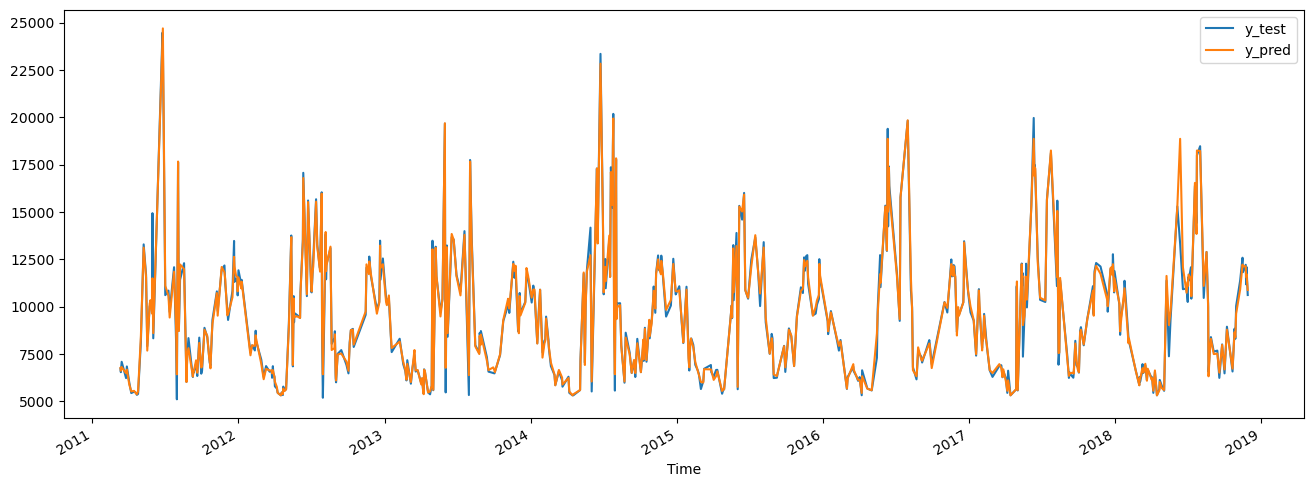

In [ ]:
df_results.plot(figsize=(16, 6))

In [ ]:
len(df_results)

570

In [ ]:
test_idx = df_results.index.sort_values()[310:340]

<Axes: xlabel='Time'>

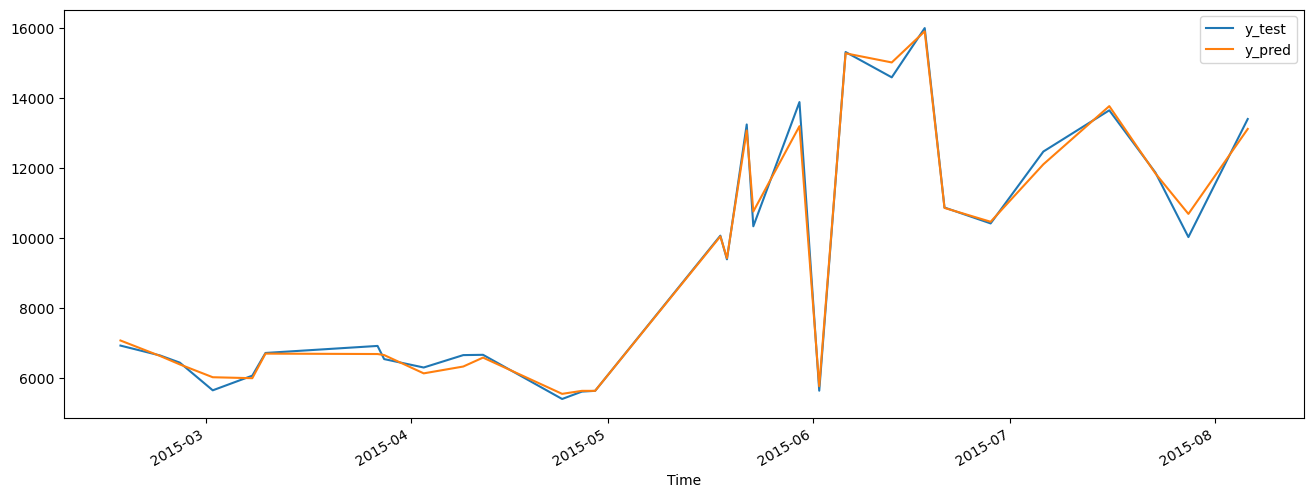

In [ ]:
df_results.loc[test_idx].plot(figsize=(16, 6))

In [ ]:
# df_daily.to_csv("./data/df_daily_feature_lags.csv")